# 06e — Semantic Retrieval Fix and Regression Audit

本 notebook 在 06d 的知识库上修正检索逻辑，不重新下载文件，也不调用任何 LLM/API。

本轮解决五个已确认问题：

1. 为可以明确解释的 P0 议案补充人工政策对象；
2. 将真正包含多个政策对象的议案排除在单对象预测之外；
3. 统一 `VAT / value added tax`、`private / independent school` 等同义表达；
4. 降低 `Second Reading`、`Clause`、`Commencement` 等程序性文字的检索权重；
5. 将“返回了证据”与“存在直接政策证据”分开审计。

输出用于决定是否可以进入 07 的小规模付费 LLM 评测。

In [1]:
# 导入数据处理、稀疏矩阵、绘图和文件输出所需的库。
from pathlib import Path
from collections import defaultdict
import hashlib
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 160)
pd.set_option('display.width', 240)
pd.set_option('display.max_colwidth', 220)

NOTEBOOK_VERSION = '06e-rag-semantic-v4'
RANDOM_STATE = 42
PARTIES = ['conservative', 'green', 'labour', 'liberal-democrat']

ROOT = Path.cwd()
MODEL_DIR = ROOT / 'processed' / 'model_v2'
RAG_V3_DIR = ROOT / 'processed' / 'rag_v3'
AUDIT_V2_DIR = ROOT / 'processed' / 'rag_audit_v2'
AUDIT_V3_DIR = ROOT / 'processed' / 'rag_audit_v3'
AUDIT_V4_DIR = ROOT / 'processed' / 'rag_audit_v4'
AUDIT_V4_DIR.mkdir(parents=True, exist_ok=True)

VALIDATION_PATH = MODEL_DIR / 'model_validation_v2.csv'
CHUNKS_V3_PATH = RAG_V3_DIR / 'rag_chunks_v3.csv'
AUDIT_SAMPLE_PATH = AUDIT_V2_DIR / 'audit_divisions_v2.csv'
V3_EVIDENCE_PATH = AUDIT_V3_DIR / 'retrieval_v3_evidence.csv'
V3_QUERY_PATH = AUDIT_V3_DIR / 'corpus_gap_queries.csv'

MAX_RESULTS = 8
MAX_POLICY_RESULTS = 2
MAX_HISTORICAL_RESULTS = 4
MAX_BILL_RESULTS = 1
MAX_CHUNKS_PER_DOCUMENT = 2

print('Notebook version:', NOTEBOOK_VERSION)
print('API calls enabled: False')
print('LLM calls enabled: False')
print('Reuses RAG v3 corpus: True')

Notebook version: 06e-rag-semantic-v4
API calls enabled: False
LLM calls enabled: False
Reuses RAG v3 corpus: True


## 1. Load the fixed audit sample and RAG v3 corpus

这里继续使用 06c/06d 的同一批 24 个 validation 议案，因此 V3 和 V4 可以直接比较。

In [2]:
# 读取固定审计样本、验证集字段、v3知识库和v3结果。
validation = pd.read_csv(VALIDATION_PATH, low_memory=False)
audit_divisions = pd.read_csv(AUDIT_SAMPLE_PATH, low_memory=False)
chunks_v3 = pd.read_csv(CHUNKS_V3_PATH, low_memory=False)
v3_evidence = pd.read_csv(V3_EVIDENCE_PATH, low_memory=False)
v3_queries = pd.read_csv(V3_QUERY_PATH, low_memory=False)

for frame, column in [
    (validation, 'motion_date'),
    (audit_divisions, 'motion_date'),
    (chunks_v3, 'source_date'),
    (v3_evidence, 'query_date'),
    (v3_queries, 'query_date'),
]:
    frame[column] = pd.to_datetime(frame[column], errors='coerce')

# 从验证集补充审计样本中没有保留的多领域计数和文本长度。
division_features = (
    validation.sort_values(['division_key', 'party'])
    .drop_duplicates('division_key')[[
        'division_key', 'policy_domain_count', 'motion_char_count'
    ]]
)
audit_divisions = audit_divisions.merge(
    division_features,
    on='division_key',
    how='left',
    validate='one_to_one',
)

chunks_v3['retrieval_text'] = chunks_v3['retrieval_text'].fillna('').astype(str)
chunks_v3['evidence_text'] = chunks_v3['evidence_text'].fillna('').astype(str)
chunks_v3['title'] = chunks_v3['title'].fillna('').astype(str)

assert audit_divisions['division_key'].nunique() == 24
assert set(PARTIES).issubset(set(validation['party'].dropna().unique()))
assert chunks_v3['chunk_id'].is_unique

display(pd.DataFrame({
    'dataset': ['audit_divisions', 'rag_v3_chunks', 'v3_evidence'],
    'rows': [len(audit_divisions), len(chunks_v3), len(v3_evidence)],
}))

,dataset,rows
0,audit_divisions,24
1,rag_v3_chunks,4942
2,v3_evidence,496


## 2. Define policy-object overrides

这张表只修正已经人工确认的查询定义，不修改投票标签：

- 两个综合国王演讲修正案保留在审计记录中，但不用于单一政策对象预测；
- two-child limit 和 primary healthcare 议案补充明确政策对象；
- private-school VAT 标题虽然可读，但补充标准化对象，帮助检索同义表达。

In [3]:
# 建立可审计的人工查询覆盖表。
query_overrides = pd.DataFrame([
    {
        'division_key': 'pw-2024-07-23-2-commons',
        'override_action': 'exclude_multi_issue',
        'policy_object_override': pd.NA,
        'override_reason': 'The amendment combines defence, migration, farming, welfare, energy and taxation.',
    },
    {
        'division_key': 'pw-2024-07-23-3-commons',
        'override_action': 'set_policy_object',
        'policy_object_override': 'Immediate abolition of the two-child limit for Universal Credit.',
        'override_reason': 'The motion text contains one clear operational policy request.',
    },
    {
        'division_key': 'pw-2024-07-23-4-commons',
        'override_action': 'exclude_multi_issue',
        'policy_object_override': pd.NA,
        'override_reason': 'The amendment combines healthcare, sewage, poverty, farming and electoral reform.',
    },
    {
        'division_key': 'pw-2024-10-16-21-commons',
        'override_action': 'set_policy_object',
        'policy_object_override': (
            'Keep the original opposition motion calling for improved access to GPs, '
            'NHS dentists, mental health care and community pharmacies, including a '
            'right to see a GP within seven days or within 24 hours when urgent.'
        ),
        'override_reason': 'The vote asks whether the original words should remain in the motion.',
    },
    {
        'division_key': 'pw-2024-11-06-34-commons',
        'override_action': 'set_policy_object',
        'policy_object_override': 'Charge value added tax on private and independent school fees.',
        'override_reason': 'The legal clause title is clear after expanding VAT and school terminology.',
    },
])

query_overrides.to_csv(
    AUDIT_V4_DIR / 'query_definition_overrides_v4.csv',
    index=False,
)
display(query_overrides)

,division_key,override_action,policy_object_override,override_reason
0,pw-2024-07-23-2-commons,exclude_multi_issue,<NA>,"The amendment combines defence, migration, farming, welfare, energy and taxation."
1,pw-2024-07-23-3-commons,set_policy_object,Immediate abolition of the two-child limit for Universal Credit.,The motion text contains one clear operational policy request.
2,pw-2024-07-23-4-commons,exclude_multi_issue,<NA>,"The amendment combines healthcare, sewage, poverty, farming and electoral reform."
3,pw-2024-10-16-21-commons,set_policy_object,"Keep the original opposition motion calling for improved access to GPs, NHS dentists, mental health care and community pharmacies, including a right to see a GP within seven days or within 24 hours when urgent.",The vote asks whether the original words should remain in the motion.
4,pw-2024-11-06-34-commons,set_policy_object,Charge value added tax on private and independent school fees.,The legal clause title is clear after expanding VAT and school terminology.


In [4]:
# 应用人工覆盖，并为其余议案沿用明确对象或保守标题fallback。
audit_v4 = audit_divisions.merge(
    query_overrides,
    on='division_key',
    how='left',
    validate='one_to_one',
)

def safe_text(value):
    # 将缺失值安全地转换为空字符串。
    if pd.isna(value):
        return ''
    return re.sub(r'\s+', ' ', str(value)).strip()


def resolve_query_definition(row):
    # 优先使用人工覆盖，其次使用既有政策对象，最后才使用标题。
    action = safe_text(row.get('override_action'))
    if action == 'exclude_multi_issue':
        return pd.Series({
            'query_readiness_v4': 'excluded_multi_issue',
            'prediction_eligible_v4': False,
            'effective_policy_object_v4': '',
        })
    if action == 'set_policy_object':
        return pd.Series({
            'query_readiness_v4': 'manual_policy_object',
            'prediction_eligible_v4': True,
            'effective_policy_object_v4': safe_text(
                row.get('policy_object_override')
            ),
        })

    existing_object = safe_text(row.get('final_policy_object'))
    if existing_object:
        return pd.Series({
            'query_readiness_v4': 'explicit_policy_object',
            'prediction_eligible_v4': True,
            'effective_policy_object_v4': existing_object,
        })

    domain_count = pd.to_numeric(
        row.get('policy_domain_count'), errors='coerce'
    )
    motion_chars = pd.to_numeric(
        row.get('motion_char_count'), errors='coerce'
    )
    if pd.notna(domain_count) and pd.notna(motion_chars):
        if int(domain_count) >= 3 and int(motion_chars) >= 700:
            return pd.Series({
                'query_readiness_v4': 'insufficient_query_definition',
                'prediction_eligible_v4': False,
                'effective_policy_object_v4': '',
            })

    title = safe_text(row.get('motion_title_clean'))
    return pd.Series({
        'query_readiness_v4': 'title_fallback',
        'prediction_eligible_v4': bool(title),
        'effective_policy_object_v4': title,
    })


audit_v4 = pd.concat(
    [audit_v4, audit_v4.apply(resolve_query_definition, axis=1)],
    axis=1,
)

display(
    audit_v4[[
        'division_key', 'motion_title_clean', 'query_readiness_v4',
        'prediction_eligible_v4', 'effective_policy_object_v4'
    ]]
)

,division_key,motion_title_clean,query_readiness_v4,prediction_eligible_v4,effective_policy_object_v4
0,pw-2024-07-23-2-commons,Amendment: Immigration and Home Affairs,excluded_multi_issue,False,
1,pw-2024-07-23-3-commons,Immigration and Home Affairs,manual_policy_object,True,Immediate abolition of the two-child limit for Universal Credit.
2,pw-2024-07-23-4-commons,Immigration and Home Affairs,excluded_multi_issue,False,
3,pw-2024-07-25-5-commons,Approve: Criminal Justice Act 2003 (Requisite and Minimum Custodial Periods) Order 2024,title_fallback,True,Approve: Criminal Justice Act 2003 (Requisite and Minimum Custodial Periods) Order 2024
4,pw-2024-07-29-6-commons,Second Reading: Passenger Railway Services (Public Ownership) Bill,title_fallback,True,Second Reading: Passenger Railway Services (Public Ownership) Bill
5,pw-2024-09-03-7-commons,Clause 2 - Future provision of services,explicit_policy_object,True,"Proposed amendment to Clause 2 - Future provision of services: Amendment proposed: 14, page 2, line 17, at end insert (1BA) Every contract made in accordance with subsection (1A) shall place a duty on the public sect..."
6,pw-2024-09-05-13-commons,Second Reading: Great British Energy Bill,title_fallback,True,Second Reading: Great British Energy Bill
7,pw-2024-09-10-14-commons,Social Security,title_fallback,True,Social Security
8,pw-2024-10-08-16-commons,VAT: Independent Schools,explicit_policy_object,True,VAT on independent-school fees
9,pw-2024-10-08-17-commons,Farming and Food Security,explicit_policy_object,True,Continuation and full use of the stated farming support funds and farming budget


## 3. Normalize policy language and reduce procedural noise

同义词扩展只用于检索，不改写向 LLM 展示的原始证据。程序词也只从检索副本中降低权重。

In [5]:
# 定义保守同义词组和议会程序短语。
SYNONYM_GROUPS = [
    (r'\b(?:value added tax|vat)\b', ' vat value added tax '),
    (r'\b(?:private schools?|independent schools?)\b', ' private school independent school '),
    (r'\b(?:school fees?|fees paid to schools?)\b', ' school fee tuition fee '),
    (r'\b(?:two child limit|two-child limit|two child cap|two-child cap)\b', ' two child limit two child cap '),
    (r'\b(?:general practitioners?|gps?)\b', ' gp general practitioner primary care doctor '),
    (r'\b(?:national insurance contributions?|nics?)\b', ' national insurance employer contribution nic '),
    (r'\b(?:railways?|railroads?)\b', ' railway rail public transport '),
    (r'\b(?:vapes?|vaping)\b', ' vape vaping electronic cigarette '),
    (r'\b(?:tobacco|cigarettes?|smoking)\b', ' tobacco cigarette smoking '),
]

PROCEDURAL_PATTERNS = [
    r'\bfirst reading\b', r'\bsecond reading\b', r'\bthird reading\b',
    r'\bcommencement\b', r'\bquestion put\b', r'\bstanding order\b',
    r'\bthat the bill be now read\b', r'\bthat the clause stand part\b',
    r'\bnew clause\s*\d*\b', r'\bclause\s*\d+\b',
    r'\bamendment proposed\b', r'\bamendment\b',
    r'\bi beg to move\b', r'\bthe house\b',
]

CONTENT_STOP_WORDS = set(ENGLISH_STOP_WORDS).union({
    'bill', 'act', 'order', 'motion', 'reading', 'clause', 'amendment',
    'question', 'house', 'commons', 'approve', 'proposed', 'stage',
    'page', 'line', 'section', 'part', 'paragraph', 'schedule',
})


def normalize_retrieval_text(value):
    # 统一同义词并删除只表示议会程序的固定短语。
    text = safe_text(value).lower()
    text = text.replace('__', ' ')
    for pattern in PROCEDURAL_PATTERNS:
        text = re.sub(pattern, ' ', text, flags=re.IGNORECASE)
    for pattern, replacement in SYNONYM_GROUPS:
        text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)
    text = re.sub(r'[^a-z0-9£%\- ]+', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()


def content_tokens(value):
    # 提取能表示政策主题的词，排除常见词和程序词。
    text = normalize_retrieval_text(value)
    return {
        token for token in re.findall(r'[a-z][a-z\-]{2,}', text)
        if token not in CONTENT_STOP_WORDS
    }


def token_coverage(query_value, evidence_value):
    # 计算查询政策词中有多少被证据覆盖。
    query_tokens = content_tokens(query_value)
    evidence_tokens = content_tokens(evidence_value)
    if not query_tokens or not evidence_tokens:
        return 0.0
    return len(query_tokens & evidence_tokens) / len(query_tokens)


def title_content(value):
    # 生成去除程序词后的标题，用于法案或政策名称匹配。
    return normalize_retrieval_text(value)


chunks_v4 = chunks_v3.copy()
chunks_v4['retrieval_text_v4'] = (
    chunks_v4['title'].map(normalize_retrieval_text)
    + ' '
    + chunks_v4['retrieval_text'].map(normalize_retrieval_text)
).str.strip()
chunks_v4['retrieval_hash_v4'] = chunks_v4['retrieval_text_v4'].map(
    lambda value: hashlib.sha256(value.encode('utf-8')).hexdigest()
)

assert chunks_v4['retrieval_text_v4'].str.len().gt(0).all()
display(chunks_v4[['source_type', 'title', 'retrieval_text_v4']].head(5))

,source_type,title,retrieval_text_v4
0,manifesto,Change — Labour Party Manifesto 2024 | A moment where we can turn,change labour party manifesto 2024 a moment where we can turn a moment where we can turn a moment where we can turn a moment where we can turn the page on a set of ideas that over 14 years have consistently left us m...
1,manifesto,Change — Labour Party Manifesto 2024 | And an opportunity to begin,change labour party manifesto 2024 and an opportunity to begin and an opportunity to begin and an opportunity to begin and an opportunity to begin the work of national renewal a rebuilding of our country so that it o...
2,manifesto,"Change — Labour Party Manifesto 2024 | First, that politics should be driven",change labour party manifesto 2024 first that politics should be driven first that politics should be driven first that politics should be driven first that politics should be driven by a sense of service to the coun...
3,manifesto,"Change — Labour Party Manifesto 2024 | Second, that if you work",change labour party manifesto 2024 second that if you work second that if you work second that if you work second that if you work hard then whoever you are wherever you started in life britain is a country that will...
4,manifesto,Change — Labour Party Manifesto 2024 | Page 6,change labour party manifesto 2024 page 6 page 6 page 6 the world has become increasingly volatile with a major war in europe for the first time in a generation and ever greater threats to the living standards of wor...


## 4. Build rolling TF-IDF indexes

每个查询日期只使用该日期之前存在的知识库内容。IDF 也按查询日期重新拟合，因此验证阶段不会看到未来文本分布。

In [6]:
# 为17个查询日期建立严格过去的滚动TF-IDF索引。
def make_vectorizer():
    # 使用词和双词短语，同时保留法律及政策名称中的连字符。
    return TfidfVectorizer(
        lowercase=True,
        strip_accents='unicode',
        ngram_range=(1, 2),
        min_df=1,
        max_df=0.98,
        sublinear_tf=True,
        norm='l2',
        max_features=100000,
        token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z\-]{1,}\b',
    )


rolling_indexes = {}
for query_date in sorted(audit_v4['motion_date'].dropna().unique()):
    query_date = pd.Timestamp(query_date)
    available_mask = (
        chunks_v4['source_date'].notna()
        & chunks_v4['source_date'].lt(query_date)
    )
    available_indices = np.flatnonzero(available_mask.to_numpy())
    vectorizer = make_vectorizer()
    matrix = vectorizer.fit_transform(
        chunks_v4.iloc[available_indices]['retrieval_text_v4']
    )
    rolling_indexes[query_date] = {
        'indices': available_indices,
        'vectorizer': vectorizer,
        'matrix': matrix,
    }

rolling_audit = pd.DataFrame([
    {
        'query_date': date,
        'available_chunks': len(value['indices']),
        'vocabulary_size': len(value['vectorizer'].vocabulary_),
    }
    for date, value in rolling_indexes.items()
])
display(rolling_audit)

,query_date,available_chunks,vocabulary_size
0,2024-07-23,4588,64288
1,2024-07-25,4598,64407
2,2024-07-29,4601,64414
3,2024-09-03,4609,64492
4,2024-09-05,4625,64663
5,2024-09-10,4628,64665
6,2024-10-08,4644,64862
7,2024-10-09,4658,65055
8,2024-10-16,4663,65077
9,2024-10-29,4678,65233


## 5. Score candidates with policy anchors

本版本不再因为两条记录都叫 `Second Reading` 就判定相关。候选证据必须覆盖查询中的实质政策词，或者直接匹配法案/政策标题。

In [7]:
# 设置来源专属的绝对、相对和政策词覆盖门槛。
POLICY_ABS_MIN = 0.030
POLICY_RELATIVE_TO_TOP = 0.55
POLICY_ANCHOR_MIN = 0.08
POLICY_STRONG_BASE = 0.090

HISTORICAL_BASE_MIN = 0.050
HISTORICAL_RELATIVE_TO_TOP = 0.60
HISTORICAL_ANCHOR_MIN = 0.10
HISTORICAL_STRONG_BASE = 0.105

BILL_ABS_MIN = 0.080
BILL_ANCHOR_MIN = 0.12

DOMAIN_MATCH_BOOST = 0.012
ANCHOR_COVERAGE_WEIGHT = 0.120
DIRECT_MATCH_BOOST = 0.180


def build_query_text(row):
    # 对政策对象和实质标题给予较高权重，同时保留部分正文语境。
    title = normalize_retrieval_text(row.get('motion_title_clean'))
    policy_object = normalize_retrieval_text(
        row.get('effective_policy_object_v4')
    )
    legislation = normalize_retrieval_text(
        row.get('legislation_name_clean')
    )
    motion_text = normalize_retrieval_text(
        safe_text(row.get('motion_text_clean'))[:1800]
    )
    domain = safe_text(row.get('policy_domain_primary')).replace('_', ' ')
    return ' '.join([
        title, title, title,
        policy_object, policy_object, policy_object, policy_object,
        legislation, legislation,
        normalize_retrieval_text(domain),
        motion_text,
    ]).strip()


def build_query_anchor(row):
    # 锚点只包含标题、政策对象和法案名称，不包含冗长正文。
    return ' '.join([
        safe_text(row.get('motion_title_clean')),
        safe_text(row.get('effective_policy_object_v4')),
        safe_text(row.get('legislation_name_clean')),
    ])


def direct_policy_match(row, evidence_title):
    # 判断去除程序词后的政策或法案名称是否直接包含。
    evidence_value = title_content(evidence_title)
    if not evidence_value:
        return False
    query_values = [
        title_content(row.get('effective_policy_object_v4')),
        title_content(row.get('legislation_name_clean')),
        title_content(row.get('motion_title_clean')),
    ]
    for query_value in query_values:
        if not query_value:
            continue
        shorter = min(len(content_tokens(query_value)), len(content_tokens(evidence_value)))
        if shorter >= 2 and (
            query_value in evidence_value or evidence_value in query_value
        ):
            return True
    return False


def score_candidates(query_row, party):
    # 在该查询日期的严格过去索引中计算来源候选分数。
    query_date = pd.Timestamp(query_row['motion_date'])
    rolling = rolling_indexes[query_date]
    available_indices = rolling['indices']
    available = chunks_v4.iloc[available_indices].copy()

    party_ok = available['party'].isin([party, 'all'])
    division_ok = available['division_key'].ne(
        query_row['division_key']
    ).fillna(True)
    local_positions = np.flatnonzero((party_ok & division_ok).to_numpy())
    if not len(local_positions):
        return pd.DataFrame()

    query_text = build_query_text(query_row)
    query_vector = rolling['vectorizer'].transform([query_text])
    all_scores = (rolling['matrix'] @ query_vector.T).toarray().ravel()

    candidates = available.iloc[local_positions].copy()
    candidates['base_score'] = all_scores[local_positions]
    query_anchor = build_query_anchor(query_row)
    candidates['anchor_coverage'] = candidates.apply(
        lambda row: token_coverage(
            query_anchor,
            safe_text(row['title']) + ' ' + safe_text(row['retrieval_text_v4'])[:1200],
        ),
        axis=1,
    )
    candidates['direct_policy_match'] = candidates['title'].map(
        lambda value: direct_policy_match(query_row, value)
    )
    candidates['same_domain'] = (
        candidates['policy_domain'].fillna('').astype(str)
        .eq(safe_text(query_row.get('policy_domain_primary')))
    )
    candidates['domain_boost'] = np.where(
        candidates['source_type'].eq('historical_vote')
        & candidates['same_domain'],
        DOMAIN_MATCH_BOOST,
        0.0,
    )
    candidates['adjusted_score'] = (
        candidates['base_score']
        + candidates['anchor_coverage'] * ANCHOR_COVERAGE_WEIGHT
        + candidates['direct_policy_match'].astype(float) * DIRECT_MATCH_BOOST
        + candidates['domain_boost']
    )
    return candidates.sort_values(
        ['adjusted_score', 'base_score'], ascending=False
    )


def add_selected(candidate, selected, document_counts, channel):
    # 限制重复chunk和单一文档占用全部证据位置。
    if any(item['chunk_id'] == candidate['chunk_id'] for item in selected):
        return False
    document_id = candidate['document_id']
    if document_counts.get(document_id, 0) >= MAX_CHUNKS_PER_DOCUMENT:
        return False
    item = candidate.to_dict()
    item['evidence_channel'] = channel
    selected.append(item)
    document_counts[document_id] = document_counts.get(document_id, 0) + 1
    return True


def select_semantic_evidence(candidates):
    # 只有通过来源分数和政策锚点条件的记录才进入最终证据集。
    selected = []
    document_counts = {}

    policy = candidates[candidates['source_type'].eq('manifesto')].copy()
    if len(policy):
        policy_top = policy['base_score'].max()
        policy_threshold = max(
            POLICY_ABS_MIN,
            policy_top * POLICY_RELATIVE_TO_TOP,
        )
        policy = policy[
            policy['base_score'].ge(policy_threshold)
            & (
                policy['anchor_coverage'].ge(POLICY_ANCHOR_MIN)
                | policy['base_score'].ge(POLICY_STRONG_BASE)
                | policy['direct_policy_match']
            )
        ]
        for _, candidate in policy.head(MAX_POLICY_RESULTS).iterrows():
            add_selected(candidate, selected, document_counts, 'policy')

    historical = candidates[
        candidates['source_type'].eq('historical_vote')
    ].copy()
    if len(historical):
        historical_top = historical['adjusted_score'].max()
        relative_threshold = historical_top * HISTORICAL_RELATIVE_TO_TOP
        historical = historical[
            historical['adjusted_score'].ge(relative_threshold)
            & historical['base_score'].ge(HISTORICAL_BASE_MIN)
            & (
                historical['anchor_coverage'].ge(HISTORICAL_ANCHOR_MIN)
                | (
                    historical['base_score'].ge(HISTORICAL_STRONG_BASE)
                    & historical['anchor_coverage'].ge(0.04)
                )
                | historical['direct_policy_match']
            )
        ]
        for _, candidate in historical.head(MAX_HISTORICAL_RESULTS).iterrows():
            add_selected(candidate, selected, document_counts, 'historical')

    bills = candidates[candidates['source_type'].eq('bill_reference')].copy()
    bills = bills[
        bills['direct_policy_match']
        | (
            bills['base_score'].ge(BILL_ABS_MIN)
            & bills['anchor_coverage'].ge(BILL_ANCHOR_MIN)
        )
    ]
    for _, candidate in bills.head(MAX_BILL_RESULTS).iterrows():
        add_selected(candidate, selected, document_counts, 'bill')

    selected = sorted(
        selected,
        key=lambda item: (item['adjusted_score'], item['base_score']),
        reverse=True,
    )
    return selected[:MAX_RESULTS]

## 6. Retrieve evidence and calculate semantic sufficiency

`semantic_sufficient` 的含义比 06d 更严格：

- 查询对象必须明确；
- 至少出现一条直接或高覆盖政策证据；
- 通常还需要第二条独立证据；
- 一条非常强的直接历史/法案匹配可以单独通过。

In [8]:
# 对24个议案和4个政党运行免费检索。
evidence_rows = []
query_rows = []

for _, query_row in audit_v4.sort_values('audit_order').iterrows():
    for party in PARTIES:
        query_id = f"{query_row['division_key']}__{party}__semantic_v4"
        eligible = bool(query_row['prediction_eligible_v4'])
        selected = []
        if eligible:
            candidates = score_candidates(query_row, party)
            selected = select_semantic_evidence(candidates)

        direct_count = 0
        contextual_count = 0
        for rank, item in enumerate(selected, start=1):
            direct = bool(
                item['direct_policy_match']
                or item['anchor_coverage'] >= 0.20
                or (
                    item['source_type'] == 'historical_vote'
                    and item['anchor_coverage'] >= 0.15
                    and item['base_score'] >= 0.08
                )
            )
            role = 'direct_policy_evidence' if direct else 'contextual_evidence'
            direct_count += int(direct)
            contextual_count += int(not direct)
            evidence_rows.append({
                'query_id': query_id,
                'query_division_key': query_row['division_key'],
                'query_party': party,
                'query_date': query_row['motion_date'],
                'query_title': query_row['motion_title_clean'],
                'query_policy_domain': query_row['policy_domain_primary'],
                'query_readiness': query_row['query_readiness_v4'],
                'prediction_eligible': eligible,
                'effective_policy_object': query_row['effective_policy_object_v4'],
                'query_motion_excerpt': safe_text(
                    query_row['motion_text_clean']
                )[:1600],
                'rank': rank,
                'source_type': item['source_type'],
                'evidence_channel': item['evidence_channel'],
                'evidence_role_auto': role,
                'base_score': item['base_score'],
                'adjusted_score': item['adjusted_score'],
                'anchor_coverage': item['anchor_coverage'],
                'direct_policy_match': item['direct_policy_match'],
                'same_domain': item['same_domain'],
                'evidence_chunk_id': item['chunk_id'],
                'evidence_document_id': item['document_id'],
                'evidence_title': item['title'],
                'evidence_party': item['party'],
                'evidence_date': item['source_date'],
                'evidence_division_key': item['division_key'],
                'evidence_policy_domain': item['policy_domain'],
                'stance_label': item['stance_label'],
                'source_url': item['source_url'],
                'page_number': item['page_number'],
                'page_column': item['page_column'],
                'evidence_text': item['evidence_text'],
            })

        strong_single = any(
            bool(item['direct_policy_match'])
            and float(item['adjusted_score']) >= 0.35
            for item in selected
        )
        semantic_sufficient = bool(
            eligible
            and direct_count >= 1
            and (len(selected) >= 2 or strong_single)
        )
        if not eligible:
            sufficiency = query_row['query_readiness_v4']
        elif semantic_sufficient:
            sufficiency = 'semantic_sufficient'
        elif len(selected) == 0:
            sufficiency = 'no_relevant_evidence'
        elif direct_count == 0:
            sufficiency = 'context_only'
        else:
            sufficiency = 'single_source_or_thin_evidence'

        query_rows.append({
            'query_id': query_id,
            'query_division_key': query_row['division_key'],
            'query_party': party,
            'query_date': query_row['motion_date'],
            'query_title': query_row['motion_title_clean'],
            'query_policy_domain': query_row['policy_domain_primary'],
            'query_readiness': query_row['query_readiness_v4'],
            'prediction_eligible': eligible,
            'effective_policy_object': query_row['effective_policy_object_v4'],
            'results': len(selected),
            'direct_evidence': direct_count,
            'contextual_evidence': contextual_count,
            'manifesto_results': sum(
                item['source_type'] == 'manifesto' for item in selected
            ),
            'historical_results': sum(
                item['source_type'] == 'historical_vote' for item in selected
            ),
            'bill_results': sum(
                item['source_type'] == 'bill_reference' for item in selected
            ),
            'semantic_sufficient': semantic_sufficient,
            'evidence_sufficiency': sufficiency,
        })

evidence_v4 = pd.DataFrame(evidence_rows)
queries_v4 = pd.DataFrame(query_rows)

assert len(queries_v4) == 24 * 4
assert not evidence_v4.duplicated(['query_id', 'evidence_chunk_id']).any()
assert evidence_v4.groupby('query_id').size().le(MAX_RESULTS).all()
assert (
    pd.to_datetime(evidence_v4['evidence_date'])
    < pd.to_datetime(evidence_v4['query_date'])
).all()
assert evidence_v4['query_division_key'].ne(
    evidence_v4['evidence_division_key']
).fillna(True).all()

display(queries_v4['evidence_sufficiency'].value_counts().to_frame('queries'))
display(evidence_v4['source_type'].value_counts().to_frame('evidence_rows'))

,queries
evidence_sufficiency,
semantic_sufficient,87
excluded_multi_issue,8
single_source_or_thin_evidence,1


,evidence_rows
source_type,
historical_vote,271
manifesto,151
bill_reference,32


## 7. Regression checks for known failures

这些检查不是模型成绩，而是确保 06e 修复了人工审核中已经发现的具体错误。

In [9]:
# 定义针对已知失败案例的可重复回归检查。
def evidence_match(division_key, party, pattern, source_type=None):
    # 检查某个查询是否找回指定标题或正文模式。
    subset = evidence_v4[
        evidence_v4['query_division_key'].eq(division_key)
        & evidence_v4['query_party'].eq(party)
    ]
    if source_type is not None:
        subset = subset[subset['source_type'].eq(source_type)]
    combined = (
        subset['evidence_title'].fillna('')
        + ' '
        + subset['evidence_text'].fillna('')
    )
    return combined.str.contains(pattern, case=False, regex=True).any()


def no_evidence_match(division_key, party, pattern, source_type=None):
    # 检查已知无关模式是否已经从证据中消失。
    return not evidence_match(division_key, party, pattern, source_type)


regression_checks = pd.DataFrame([
    {
        'check_id': 'multi_issue_conservative_speech_excluded',
        'passed': not queries_v4.loc[
            queries_v4['query_division_key'].eq('pw-2024-07-23-2-commons'),
            'prediction_eligible'
        ].any(),
        'severity': 'critical',
    },
    {
        'check_id': 'multi_issue_libdem_speech_excluded',
        'passed': not queries_v4.loc[
            queries_v4['query_division_key'].eq('pw-2024-07-23-4-commons'),
            'prediction_eligible'
        ].any(),
        'severity': 'critical',
    },
    {
        'check_id': 'two_child_limit_query_recovered',
        'passed': queries_v4.loc[
            queries_v4['query_division_key'].eq('pw-2024-07-23-3-commons'),
            'prediction_eligible'
        ].all(),
        'severity': 'critical',
    },
    {
        'check_id': 'primary_care_query_recovered',
        'passed': queries_v4.loc[
            queries_v4['query_division_key'].eq('pw-2024-10-16-21-commons'),
            'prediction_eligible'
        ].all(),
        'severity': 'critical',
    },
    {
        'check_id': 'labour_vat_manifesto_retrieved',
        'passed': evidence_match(
            'pw-2024-11-06-34-commons', 'labour',
            r'VAT exemption|business rates relief for private', 'manifesto'
        ),
        'severity': 'critical',
    },
    {
        'check_id': 'labour_vat_history_retrieved',
        'passed': evidence_match(
            'pw-2024-11-06-34-commons', 'labour',
            r'VAT: Independent Schools', 'historical_vote'
        ),
        'severity': 'critical',
    },
    {
        'check_id': 'libdem_vat_history_retrieved',
        'passed': evidence_match(
            'pw-2024-11-06-34-commons', 'liberal-democrat',
            r'VAT: Independent Schools', 'historical_vote'
        ),
        'severity': 'critical',
    },
    {
        'check_id': 'green_tobacco_unrelated_second_readings_removed',
        'passed': no_evidence_match(
            'pw-2024-11-26-48-commons', 'green',
            r'Health and Care Bill|Trade Bill|Health and Social Care Levy Bill|Elections Bill',
            'historical_vote'
        ),
        'severity': 'critical',
    },
    {
        'check_id': 'green_energy_migration_chunk_removed',
        'passed': no_evidence_match(
            'pw-2024-10-29-24-commons', 'green',
            r'fleeing persecution|migration is inevitable', 'manifesto'
        ),
        'severity': 'warning',
    },
    {
        'check_id': 'all_evidence_strictly_before_query',
        'passed': (
            pd.to_datetime(evidence_v4['evidence_date'])
            < pd.to_datetime(evidence_v4['query_date'])
        ).all(),
        'severity': 'critical',
    },
])

regression_checks['passed'] = regression_checks['passed'].astype(bool)
display(regression_checks)

,check_id,passed,severity
0,multi_issue_conservative_speech_excluded,True,critical
1,multi_issue_libdem_speech_excluded,True,critical
2,two_child_limit_query_recovered,True,critical
3,primary_care_query_recovered,True,critical
4,labour_vat_manifesto_retrieved,True,critical
5,labour_vat_history_retrieved,True,critical
6,libdem_vat_history_retrieved,True,critical
7,green_tobacco_unrelated_second_readings_removed,True,critical
8,green_energy_migration_chunk_removed,False,warning
9,all_evidence_strictly_before_query,True,critical


## 8. Compare V3 and V4

V4 的目标不是重新补满八条，而是提高可解释、直接政策证据的比例。

In [10]:
# 计算v3与v4的可比较覆盖指标。
v3_query_count = v3_queries['query_id'].nunique()
v3_prediction_rate = v3_queries['prediction_eligible'].astype(bool).mean()
v3_sufficient_rate = v3_queries['evidence_sufficiency'].eq(
    'sufficient_for_llm_review'
).mean()

eligible_v4 = queries_v4[queries_v4['prediction_eligible']].copy()
in_scope_v4 = queries_v4[
    queries_v4['query_readiness'].ne('excluded_multi_issue')
].copy()

comparison = pd.DataFrame({
    'metric': [
        'prediction_eligible_rate',
        'sufficient_evidence_rate',
        'mean_results_per_query',
        'manifesto_query_coverage_rate',
        'bill_query_coverage_rate',
    ],
    'v3': [
        v3_prediction_rate,
        v3_sufficient_rate,
        v3_queries['results'].mean(),
        v3_queries['manifesto_results'].gt(0).mean(),
        v3_queries['bill_results'].gt(0).mean(),
    ],
    'v4': [
        queries_v4['prediction_eligible'].mean(),
        eligible_v4['semantic_sufficient'].mean(),
        queries_v4['results'].mean(),
        queries_v4['manifesto_results'].gt(0).mean(),
        queries_v4['bill_results'].gt(0).mean(),
    ],
})
display(comparison)

party_metrics = (
    queries_v4.groupby('query_party')
    .agg(
        queries=('query_id', 'size'),
        eligible_rate=('prediction_eligible', 'mean'),
        semantic_sufficient_rate=('semantic_sufficient', 'mean'),
        mean_results=('results', 'mean'),
        mean_direct_evidence=('direct_evidence', 'mean'),
    )
    .reset_index()
)
display(party_metrics)

,metric,v3,v4
0,prediction_eligible_rate,0.833333,0.916667
1,sufficient_evidence_rate,0.833333,0.988636
2,mean_results_per_query,5.166667,4.729167
3,manifesto_query_coverage_rate,0.989583,0.895833
4,bill_query_coverage_rate,0.250000,0.333333


,query_party,queries,eligible_rate,semantic_sufficient_rate,mean_results,mean_direct_evidence
0,conservative,24,0.916667,0.916667,4.541667,4.208333
1,green,24,0.916667,0.875000,4.625000,4.125000
2,labour,24,0.916667,0.916667,4.666667,4.333333
3,liberal-democrat,24,0.916667,0.916667,5.083333,4.500000


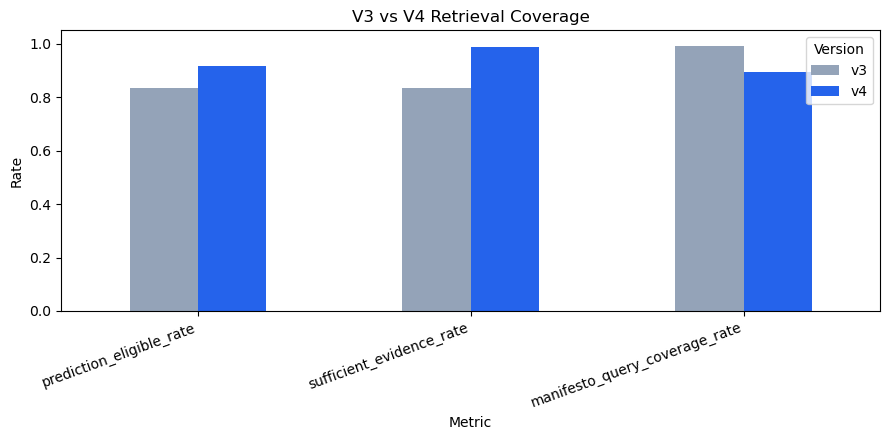

In [11]:
# 用一张简洁图比较v3与v4的核心覆盖率。
plot_data = comparison[
    comparison['metric'].isin([
        'prediction_eligible_rate',
        'sufficient_evidence_rate',
        'manifesto_query_coverage_rate',
    ])
].set_index('metric')[['v3', 'v4']]

ax = plot_data.plot(
    kind='bar',
    figsize=(9, 4.5),
    color=['#94A3B8', '#2563EB'],
)
ax.set_title('V3 vs V4 Retrieval Coverage')
ax.set_xlabel('Metric')
ax.set_ylabel('Rate')
ax.set_ylim(0, 1.05)
ax.legend(title='Version')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## 9. Build the remaining gap list and manual review queue

只有 V4 仍然证据不足的查询，以及回归检查涉及的关键议案，才进入下一轮人工审核。

In [12]:
# 为每个查询生成下一步处理建议。
def assign_gap(row):
    # 将查询定义、证据缺失和已通过状态分开。
    if row['query_readiness'] == 'excluded_multi_issue':
        return pd.Series({
            'gap_priority': 'EXCLUDE',
            'gap_type': 'multi_issue_motion',
            'recommended_action': 'keep_out_of_single_object_prediction',
        })
    if not row['prediction_eligible']:
        return pd.Series({
            'gap_priority': 'P0',
            'gap_type': 'query_definition_gap',
            'recommended_action': 'review_policy_object',
        })
    if row['evidence_sufficiency'] == 'no_relevant_evidence':
        return pd.Series({
            'gap_priority': 'P1',
            'gap_type': 'no_relevant_evidence',
            'recommended_action': 'search_specific_official_source',
        })
    if row['evidence_sufficiency'] == 'context_only':
        return pd.Series({
            'gap_priority': 'P1',
            'gap_type': 'no_direct_policy_evidence',
            'recommended_action': 'improve_query_or_add_specific_source',
        })
    if row['evidence_sufficiency'] == 'single_source_or_thin_evidence':
        return pd.Series({
            'gap_priority': 'P2',
            'gap_type': 'thin_direct_evidence',
            'recommended_action': 'manual_review_before_llm',
        })
    return pd.Series({
        'gap_priority': 'OK',
        'gap_type': 'no_blocking_gap',
        'recommended_action': 'eligible_for_small_llm_evaluation',
    })


gap_table = pd.concat(
    [queries_v4, queries_v4.apply(assign_gap, axis=1)],
    axis=1,
)

review_query_ids = set(
    gap_table.loc[
        gap_table['gap_priority'].isin(['P0', 'P1', 'P2']),
        'query_id'
    ]
)

regression_divisions = {
    'pw-2024-07-23-3-commons',
    'pw-2024-10-16-21-commons',
    'pw-2024-10-29-24-commons',
    'pw-2024-11-06-34-commons',
    'pw-2024-11-26-48-commons',
}
review_query_ids.update(
    gap_table.loc[
        gap_table['query_division_key'].isin(regression_divisions),
        'query_id'
    ]
)

manual_queue = evidence_v4[
    evidence_v4['query_id'].isin(review_query_ids)
].copy()
manual_queue['evidence_text_excerpt'] = manual_queue['evidence_text'].map(
    lambda value: safe_text(value)[:1400]
)
manual_queue['manual_relevance'] = ''
manual_queue['manual_evidence_role'] = ''
manual_queue['manual_notes'] = ''

display(gap_table['gap_priority'].value_counts().to_frame('queries'))
display(
    gap_table[gap_table['gap_priority'].ne('OK')][[
        'query_division_key', 'query_party', 'query_title',
        'evidence_sufficiency', 'results', 'direct_evidence',
        'gap_priority', 'recommended_action'
    ]]
)

,queries
gap_priority,
OK,87
EXCLUDE,8
P2,1


,query_division_key,query_party,query_title,evidence_sufficiency,results,direct_evidence,gap_priority,recommended_action
0,pw-2024-07-23-2-commons,conservative,Amendment: Immigration and Home Affairs,excluded_multi_issue,0,0,EXCLUDE,keep_out_of_single_object_prediction
1,pw-2024-07-23-2-commons,green,Amendment: Immigration and Home Affairs,excluded_multi_issue,0,0,EXCLUDE,keep_out_of_single_object_prediction
2,pw-2024-07-23-2-commons,labour,Amendment: Immigration and Home Affairs,excluded_multi_issue,0,0,EXCLUDE,keep_out_of_single_object_prediction
3,pw-2024-07-23-2-commons,liberal-democrat,Amendment: Immigration and Home Affairs,excluded_multi_issue,0,0,EXCLUDE,keep_out_of_single_object_prediction
8,pw-2024-07-23-4-commons,conservative,Immigration and Home Affairs,excluded_multi_issue,0,0,EXCLUDE,keep_out_of_single_object_prediction
9,pw-2024-07-23-4-commons,green,Immigration and Home Affairs,excluded_multi_issue,0,0,EXCLUDE,keep_out_of_single_object_prediction
10,pw-2024-07-23-4-commons,labour,Immigration and Home Affairs,excluded_multi_issue,0,0,EXCLUDE,keep_out_of_single_object_prediction
11,pw-2024-07-23-4-commons,liberal-democrat,Immigration and Home Affairs,excluded_multi_issue,0,0,EXCLUDE,keep_out_of_single_object_prediction
77,pw-2024-11-26-48-commons,green,Second Reading: Tobacco and Vapes Bill,single_source_or_thin_evidence,1,1,P2,manual_review_before_llm


## 10. Acceptance gates and saved outputs

只有关键回归检查全部通过，并且每个政党都具备最低语义证据覆盖，才建议进入 07。

In [13]:
# 计算进入小规模LLM评测前的验收门槛。
critical_regression_gate = regression_checks.loc[
    regression_checks['severity'].eq('critical'), 'passed'
].all()
eligible_semantic_rate = eligible_v4['semantic_sufficient'].mean()
worst_party_semantic_rate = party_metrics['semantic_sufficient_rate'].min()

acceptance_gates = {
    'critical_regression_gate': bool(critical_regression_gate),
    'eligible_semantic_sufficiency_gate': bool(
        eligible_semantic_rate >= 0.75
    ),
    'worst_party_semantic_sufficiency_gate': bool(
        worst_party_semantic_rate >= 0.60
    ),
    'temporal_leakage_gate': bool((
        pd.to_datetime(evidence_v4['evidence_date'])
        < pd.to_datetime(evidence_v4['query_date'])
    ).all()),
    'same_division_gate': bool(
        evidence_v4['query_division_key'].ne(
            evidence_v4['evidence_division_key']
        ).fillna(True).all()
    ),
}

ready_for_07 = all(acceptance_gates.values())

evidence_v4.to_csv(
    AUDIT_V4_DIR / 'retrieval_v4_evidence.csv', index=False
)
queries_v4.to_csv(
    AUDIT_V4_DIR / 'retrieval_v4_query_metrics.csv', index=False
)
gap_table.to_csv(
    AUDIT_V4_DIR / 'corpus_gap_queries_v4.csv', index=False
)
regression_checks.to_csv(
    AUDIT_V4_DIR / 'retrieval_regression_checks_v4.csv', index=False
)
manual_queue.to_csv(
    AUDIT_V4_DIR / 'manual_relevance_review_queue_v4.csv', index=False
)
comparison.to_csv(
    AUDIT_V4_DIR / 'v3_v4_comparison.csv', index=False
)
party_metrics.to_csv(
    AUDIT_V4_DIR / 'party_retrieval_metrics_v4.csv', index=False
)

print('=== SEMANTIC RETRIEVAL V4 SUMMARY FOR REVIEW ===')
print('Notebook version:', NOTEBOOK_VERSION)
print('API calls: 0')
print('LLM calls: 0')
print('Audit divisions:', audit_v4['division_key'].nunique())
print('Audit party queries:', len(queries_v4))
print('Excluded multi-issue divisions:', int(
    audit_v4['query_readiness_v4'].eq('excluded_multi_issue').sum()
))
print('Prediction-eligible query rate:', round(
    queries_v4['prediction_eligible'].mean(), 3
))
print('Semantic-sufficient rate among eligible queries:', round(
    eligible_semantic_rate, 3
))
print('Mean evidence per query:', round(queries_v4['results'].mean(), 3))
print('Mean direct evidence per eligible query:', round(
    eligible_v4['direct_evidence'].mean(), 3
))
print('Critical regression checks passed:', bool(critical_regression_gate))
print('Acceptance gates:', acceptance_gates)
print('Ready for small paid 07 evaluation:', ready_for_07)
print('Evidence sufficiency:')
print(queries_v4['evidence_sufficiency'].value_counts().to_string())
print('Party metrics:')
print(party_metrics.to_string(index=False))
print('Regression checks:')
print(regression_checks.to_string(index=False))
print('Gap priorities:')
print(gap_table['gap_priority'].value_counts().to_string())
print('Output directory:', AUDIT_V4_DIR)
if ready_for_07:
    print('Next step: run a small, capped 07 LLM evaluation.')
else:
    print('Next step: inspect only failed regression checks and remaining P1/P2 queries before 07.')
print('=== END SEMANTIC RETRIEVAL V4 SUMMARY ===')

=== SEMANTIC RETRIEVAL V4 SUMMARY FOR REVIEW ===
Notebook version: 06e-rag-semantic-v4
API calls: 0
LLM calls: 0
Audit divisions: 24
Audit party queries: 96
Excluded multi-issue divisions: 2
Prediction-eligible query rate: 0.917
Semantic-sufficient rate among eligible queries: 0.989
Mean evidence per query: 4.729
Mean direct evidence per eligible query: 4.682
Critical regression checks passed: True
Acceptance gates: {'critical_regression_gate': True, 'eligible_semantic_sufficiency_gate': True, 'worst_party_semantic_sufficiency_gate': True, 'temporal_leakage_gate': True, 'same_division_gate': True}
Ready for small paid 07 evaluation: True
Evidence sufficiency:
evidence_sufficiency
semantic_sufficient               87
excluded_multi_issue               8
single_source_or_thin_evidence     1
Party metrics:
     query_party  queries  eligible_rate  semantic_sufficient_rate  mean_results  mean_direct_evidence
    conservative       24       0.916667                  0.916667      4.541667  

## How to read the result

- `Critical regression checks passed = True`：已知的具体错误已经修复。
- `semantic_sufficient`：至少存在一条直接政策证据，并满足最低证据组合条件。
- `context_only`：内容相关，但不足以支持政党立场判断。
- `single_source_or_thin_evidence`：存在直接线索，但证据仍偏薄。
- `excluded_multi_issue`：议案同时包含多个政策对象，不适合当前单对象预测任务。

即使验收门通过，07 也只应先测一个小样本，不应直接对整个 Test 集调用 API。